# 05 — Traditional Story Building

## What this notebook does

**Part 1 — Keyword Extraction (§3.2.1)**
Extracts TF-IDF keywords per article using Bulgarian stopwords.
Saves `data/processed/keywords.pkl`.

**Part 2 — Story Building (§3.2.2 — §3.2.3)**
Implements the NewsLens paper pipeline:
- Sliding window: 5-day windows, 2-day step
- Graph edges: keyword Jaccard similarity with `T2=6`
- Story linking: majority vote + cross-gap cosine merge with `T3=0.8`
- Parameter sweep over T2 and T3 to select best configuration

**Part 3 — Story Evaluation**
Evaluates story quality using intra-story coherence, inter-story separation,
and coverage. Serves as the traditional baseline for comparison in notebook 06.

## Result files
- `data/processed/keywords.pkl` — TF-IDF keywords per article

## Note
This notebook implements the **traditional baseline** from the NewsLens paper.


In [1]:
from pathlib import Path
import pickle
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import networkx as nx
import community as community_louvain
from sklearn.preprocessing import normalize
from sklearn.feature_extraction import DictVectorizer
import stanza
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import matplotlib.cm as cm
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_sk

In [ ]:
REPO_ROOT = Path("../").resolve()
PARQUET_PATH = REPO_ROOT / "data" / "processed" / "articles_clean.parquet"

RANDOM_SEED=42
N_DAYS = 5
STEP = 2

# Load df

In [4]:
df = pd.read_parquet(PARQUET_PATH)
df["published_at_dt"] = pd.to_datetime(df["published_at_dt"], utc=True)

dates = (
    df["published_at_dt"].dt.tz_localize(None)
    if df["published_at_dt"].dt.tz is not None
    else df["published_at_dt"]
)
dates = dates.dt.normalize()  # floor to day

start_date = dates.min()
end_date = dates.max()

windows = []
window_start = start_date
while window_start + timedelta(days=N_DAYS) <= end_date + timedelta(days=1):
    window_end = window_start + timedelta(days=N_DAYS)
    windows.append((window_start, window_end))
    window_start += timedelta(days=STEP)

print(f"Articles  : {len(df):,}")
print(f"Date range  : {start_date.date()} → {end_date.date()}")
print(f"Window size : {N_DAYS} days, step {STEP} days")
print(f"Total windows: {len(windows)}")
print()
for i, (ws, we) in enumerate(windows[:5]):
    mask = (dates >= ws) & (dates < we)
    print(f"Window {i+1}: {ws.date()} → {we.date()}  ({mask.sum()} articles)")
print("...")

Articles  : 30,462
Date range  : 2026-04-20 → 2026-05-22
Window size : 5 days, step 2 days
Total windows: 15

Window 1: 2026-04-20 → 2026-04-25  (3118 articles)
Window 2: 2026-04-22 → 2026-04-27  (3217 articles)
Window 3: 2026-04-24 → 2026-04-29  (3244 articles)
Window 4: 2026-04-26 → 2026-05-01  (3482 articles)
Window 5: 2026-04-28 → 2026-05-03  (3334 articles)
...


In [5]:
BG_STOPWORDS = {
    "на", "в", "за", "от", "с", "до", "по", "при", "към", "над",
    "под", "пред", "зад", "без", "между", "около", "освен", "чрез",
    "след", "преди", "и", "или", "но", "че", "като", "когато",
    "който", "която", "което", "които", "да", "се", "си", "съм",
    "е", "сме", "сте", "са", "бях", "беше", "бяхме", "бяхте",
    "бяха", "ще", "би", "бих", "биха", "не", "ни",
    "аз", "ти", "той", "тя", "то", "ние", "вие", "те", "го", "я",
    "им", "ги", "му", "й", "ми", "това", "тази", "този",
    "тези", "онова", "онази", "онзи", "онези", "вече", "още", "само",
    "дори", "обаче", "също", "затова", "защото", "въпреки", "докато",
    "откакто", "ако", "дали", "нито", "нали", "пък", "ама", "та",
    "а", "сега", "тук", "там", "така", "тогава", "днес",
    "утре", "вчера", "много", "малко", "повече", "бе", "нея",
    "него", "нас", "вас", "тях",
}
print(f"BG stopwords: {len(BG_STOPWORDS)}")


BG stopwords: 108


# Pipeline functions

In [6]:
def build_keywords(df, T=0.11, MAX_DF=0.30, batch_size=1000, random_seed=RANDOM_SEED):
    """3.2.1 — TF-IDF keyword extraction + Stanza lemmatization + stopword filtering."""

    texts = df["full_text"].fillna("").tolist()
    shuffled_idx = np.random.default_rng(random_seed).permutation(len(texts))
    keywords_per_article = [None] * len(texts)

    for batch_start in tqdm(range(0, len(texts), batch_size), desc="3.2.1 TF-IDF"):
        batch_idx = shuffled_idx[batch_start : batch_start + batch_size]
        batch_texts = [texts[i] for i in batch_idx]
        count_vec = CountVectorizer()
        bow = count_vec.fit_transform(batch_texts)
        tfidf = TfidfTransformer().fit_transform(bow)
        vocab = count_vec.get_feature_names_out()
        tfidf_dense = tfidf.toarray()
        for local_i, global_i in enumerate(batch_idx):
            scores = tfidf_dense[local_i]
            keywords_per_article[global_i] = set(vocab[scores > T])

    all_keywords = set()
    for kw_set in keywords_per_article:
        if kw_set:
            all_keywords.update(w.lower() for w in kw_set)

    print(f"Unique keywords to lemmatize: {len(all_keywords):,}")
    nlp = stanza.Pipeline("bg", processors="tokenize,lemma", use_gpu=False)
    lemma_map = {}
    for word in tqdm(all_keywords, desc="3.2.1 Lemmatizing"):
        doc = nlp(word)
        lemma = doc.sentences[0].words[0].lemma if doc.sentences else word
        lemma = (lemma or word).split("(")[0].strip("-").strip()
        lemma_map[word] = lemma.lower() if lemma else word

    keywords_lemmatized = [
        {lemma_map[w.lower()] for w in kw_set if w.lower() in lemma_map}
        for kw_set in keywords_per_article
    ]

    total_docs = len(keywords_lemmatized)
    kw_doc_freq = Counter()
    for kw_set in keywords_lemmatized:
        kw_doc_freq.update(kw_set)
    freq_sw = {kw for kw, cnt in kw_doc_freq.items() if cnt / total_docs > MAX_DF}
    all_sw = BG_STOPWORDS | freq_sw
    keywords_out = [kw_set - all_sw for kw_set in keywords_lemmatized]

    sizes = [len(k) for k in keywords_out]
    print(f"T={T}, MAX_DF={MAX_DF} | High-freq removed: {sorted(freq_sw)}")
    print(f"Avg keywords/article: {sum(sizes)/len(sizes):.1f}")
    return keywords_out

In [7]:
keywords = build_keywords(df, T=0.11, MAX_DF=0.30)

3.2.1 TF-IDF:   0%|          | 0/31 [00:00<?, ?it/s]

2026-05-29 21:41:02 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


Unique keywords to lemmatize: 66,641


2026-05-29 21:41:03 INFO: Downloaded file to /Users/ivanadonchevska/Library/Caches/stanza/1.12.0/resources/resources.json
2026-05-29 21:41:03 INFO: Loading these models for language: bg (Bulgarian):
| Processor | Package      |
----------------------------
| tokenize  | btb          |
| lemma     | btb_nocharlm |

2026-05-29 21:41:03 INFO: Using device: cpu
2026-05-29 21:41:03 INFO: Loading: tokenize
2026-05-29 21:41:03 INFO: Loading: lemma
2026-05-29 21:41:03 INFO: Done loading processors!


3.2.1 Lemmatizing:   0%|          | 0/66641 [00:00<?, ?it/s]

T=0.11, MAX_DF=0.3 | High-freq removed: ['на']
Avg keywords/article: 14.3


In [8]:
# how many keywords does article 0 have?
print(keywords[0])

# avg keywords per article
sizes = [len(k) for k in keywords]
print(f"Avg: {sum(sizes)/len(sizes):.1f}")
print(f"Min: {min(sizes)}, Max: {max(sizes)}")

# articles with zero keywords
empty = sum(1 for k in keywords if len(k) == 0)
print(f"Articles with no keywords: {empty}")

{'твой', 'вярвам', 'песенен', 'себе', 'свой', 'евровизия', 'премиер', 'искам', 'dara'}
Avg: 14.3
Min: 0, Max: 46
Articles with no keywords: 1


In [9]:
zero_kw = [i for i, k in enumerate(keywords) if len(k) == 0]
for i in zero_kw:
    row = df.iloc[i]
    print(f"Index: {i}")
    print(f"Source : {row['source']}")
    print(f"Date   : {row['published_at_dt']}")
    print(f"Title  : {row['title']}")
    print(f"Title  : {row['url']}")
    print(f"Text   : {str(row['full_text'][:400])}")
    print("-" * 60)

Index: 8793
Source : fakti
Date   : 2026-05-15 06:00:01+00:00
Title  : Успешното управление на „Прогресивна България“ минава през формулирането на нов проект за развитие на страната
Title  : https://fakti.bg/mnenia/1054558-uspeshnoto-upravlenie-na-progresivna-balgaria-minava-prez-formuliraneto-na-nov-proekt-za-razvitie-na-stranata
Text   : Още от първите си дни новото правителство на България се опитва да демонстрира летящ старт за решаването на натрупаните много и сериозни проблеми пред управлението на държавата. От заявките на кабинета и на отделни негови членове се открояват три непосредствени приоритета:
Приемане на държавния бюджет за 2026 г.
Новият кабинет трябва в рамките на 3–4 седмици да внесе и приеме редовен бюджет, след 
------------------------------------------------------------


## Articles with Zero Keywords

After running keyword extraction, **1 out of 30,462 articles (0.003%)** received an empty keyword set despite having substantial text content.

### Long Political Opinion Piece (Fakti)
- *"Успешното управление на „Прогресивна България“ минава през формулирането на нов проект за развитие на страната"* (index 8793, 2026-05-15)

This is an analytical opinion article using broad political vocabulary (`правителство`, `управление`, `българия`, `държава`) — words that appear across hundreds of articles and are removed by the `MAX_DF=0.30` high-frequency filter as carrying no topical signal.

### Conclusion
This is expected behavior, not a pipeline error. The article genuinely lacks distinctive vocabulary: it uses generic political terminology too common across the corpus to signal a specific topic.

The impact on results is negligible (0.003% of the dataset). This article becomes a singleton and does not affect story quality.


In [10]:
with open("../data/processed/keywords.pkl", "wb") as f:
    pickle.dump(keywords, f)

print("Saved.")

Saved.


# Keywords graph building

In [11]:
def build_topics(df, keywords, dates, windows, T2=5, random_seed=RANDOM_SEED):
    """Build keyword graph per sliding window, detect topics via Louvain."""
    window_topics = []
    for ws, we in tqdm(windows, desc="Graph + Louvain"):
        mask = (dates >= ws) & (dates < we)
        win_idx_list = df.index[mask].tolist()
        G = nx.Graph()
        G.add_nodes_from(win_idx_list)
        for i in range(len(win_idx_list)):
            for j in range(i + 1, len(win_idx_list)):
                a, b = win_idx_list[i], win_idx_list[j]
                shared = keywords[a] & keywords[b]
                if len(shared) >= T2:
                    G.add_edge(a, b, weight=len(shared))
        partition = community_louvain.best_partition(G, random_state=random_seed)
        window_topics.append(partition)

    print(f"T2={T2} | {len(window_topics)} windows processed")
    for i, p in enumerate(window_topics[:3]):
        print(f"  Window {i+1}: {len(set(p.values()))} topics, {len(p)} articles")
    return window_topics

In [12]:
topics = build_topics(df, keywords, dates, windows, T2=6)

Graph + Louvain:   0%|          | 0/15 [00:00<?, ?it/s]

T2=6 | 15 windows processed
  Window 1: 2302 topics, 3118 articles
  Window 2: 2296 topics, 3217 articles
  Window 3: 2317 topics, 3244 articles


In [ ]:
rows = []
for i, (partition, (ws, we)) in enumerate(zip(topics, windows)):
    # rebuild graph for this window to get edge stats
    mask = (dates >= ws) & (dates < we)
    win_idx = df.index[mask].tolist()

    n_nodes = len(win_idx)
    n_edges = 0
    degrees = defaultdict(int)
    for ii in range(len(win_idx)):
        for jj in range(ii + 1, len(win_idx)):
            a, b = win_idx[ii], win_idx[jj]
            if len(keywords[a] & keywords[b]) >= 6:
                n_edges += 1
                degrees[a] += 1
                degrees[b] += 1

    possible = n_nodes * (n_nodes - 1) / 2
    density = n_edges / possible if possible > 0 else 0
    isolated = sum(1 for idx in win_idx if degrees[idx] == 0)
    n_comm = len(set(partition.values()))

    rows.append(
        {
            "window": f"{ws.strftime('%d %b')}",
            "nodes": n_nodes,
            "edges": n_edges,
            "density": density,
            "isolated": isolated,
            "communities": n_comm,
        }
    )
    print(
        f"W{i+1:02d} {ws.strftime('%d %b')}  nodes={n_nodes:4d}  edges={n_edges:6d}  density={density:.4f}  isolated={isolated:4d}  communities={n_comm:4d}"
    )

W01 20 Apr  nodes=3118  edges=  1457  density=0.0003  isolated=1992  communities=2302
W02 22 Apr  nodes=3217  edges=  1823  density=0.0004  isolated=1961  communities=2296
W03 24 Apr  nodes=3244  edges=  1878  density=0.0004  isolated=1966  communities=2317
W04 26 Apr  nodes=3482  edges=  1851  density=0.0003  isolated=2147  communities=2511
W05 28 Apr  nodes=3334  edges=  1606  density=0.0003  isolated=2112  communities=2460
W06 30 Apr  nodes=3246  edges=  1800  density=0.0003  isolated=1974  communities=2321
W07 02 May  nodes=4011  edges=  2773  density=0.0003  isolated=2212  communities=2670
W08 04 May  nodes=5846  edges=  5649  density=0.0003  isolated=2905  communities=3577
W09 06 May  nodes=5612  edges=  5308  density=0.0003  isolated=2723  communities=3393
W10 08 May  nodes=5931  edges=  5572  density=0.0003  isolated=2963  communities=3643
W11 10 May  nodes=6107  edges=  5285  density=0.0003  isolated=3082  communities=3761
W12 12 May  nodes=6014  edges=  5493  density=0.0003  

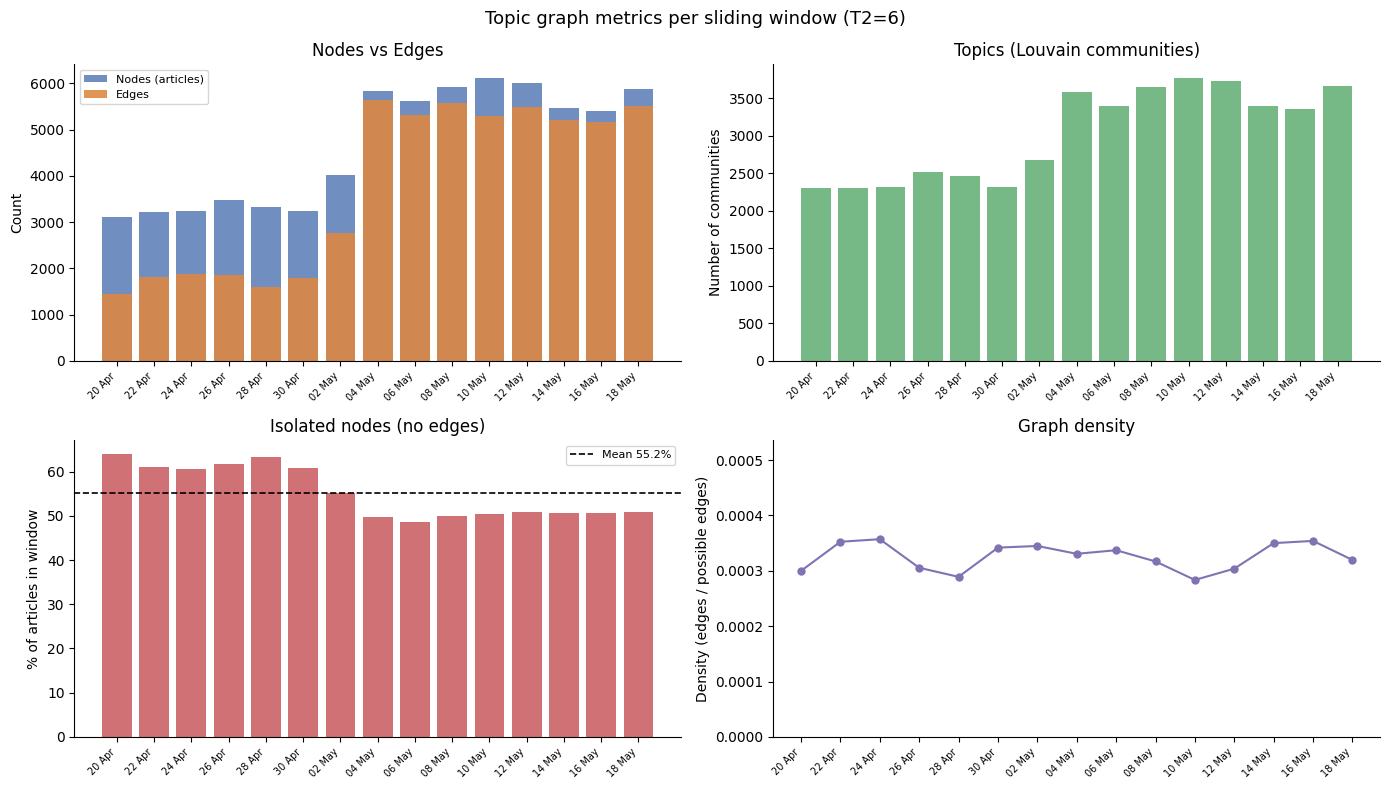

In [ ]:
labels = [r["window"] for r in rows]
nodes = [r["nodes"] for r in rows]
edges = [r["edges"] for r in rows]
isolated = [r["isolated"] for r in rows]
comms = [r["communities"] for r in rows]
iso_pct = [r["isolated"] / r["nodes"] * 100 for r in rows]
x = np.arange(len(rows))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Topic graph metrics per sliding window (T2=6)", fontsize=13)

# nodes vs edges
axes[0, 0].bar(x, nodes, color="#4C72B0", alpha=0.8, label="Nodes (articles)")
axes[0, 0].bar(x, edges, color="#DD8844", alpha=0.9, label="Edges")
axes[0, 0].set_title("Nodes vs Edges")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(fontsize=8)

# communities
axes[0, 1].bar(x, comms, color="#55A868", alpha=0.8)
axes[0, 1].set_title("Topics (Louvain communities)")
axes[0, 1].set_ylabel("Number of communities")

# isolated nodes %
axes[1, 0].bar(x, iso_pct, color="#C44E52", alpha=0.8)
axes[1, 0].axhline(
    np.mean(iso_pct),
    color="black",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean {np.mean(iso_pct):.1f}%",
)
axes[1, 0].set_title("Isolated nodes (no edges)")
axes[1, 0].set_ylabel("% of articles in window")
axes[1, 0].legend(fontsize=8)

# density
density_vals = [r["density"] for r in rows]
axes[1, 1].plot(
    x, density_vals, marker="o", color="#8172B2", linewidth=1.5, markersize=5
)
axes[1, 1].set_title("Graph density")
axes[1, 1].set_ylabel("Density (edges / possible edges)")
axes[1, 1].set_ylim(0, max(density_vals) * 1.5)

for ax in axes.flat:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

In [ ]:
def plot_window_graph(
    window_idx, topics, windows, dates, df, keywords, T2=6, min_community_size=2
):
    ws, we = windows[window_idx]
    partition = topics[window_idx]

    mask = (dates >= ws) & (dates < we)
    win_idx = df.index[mask].tolist()

    # rebuild graph
    G = nx.Graph()
    G.add_nodes_from(win_idx)
    for i in range(len(win_idx)):
        for j in range(i + 1, len(win_idx)):
            a, b = win_idx[i], win_idx[j]
            if len(keywords[a] & keywords[b]) >= T2:
                G.add_edge(a, b)

    # keep only nodes in communities of size >= min_community_size
    from collections import Counter

    comm_sizes = Counter(partition.values())
    keep = {
        node
        for node, comm in partition.items()
        if comm_sizes[comm] >= min_community_size
    }
    G_sub = G.subgraph(keep)

    # color by community
    communities = [partition[n] for n in G_sub.nodes()]
    unique_comms = list(set(communities))
    color_map = {c: i for i, c in enumerate(unique_comms)}
    colors = [color_map[c] for c in communities]

    n_nodes = G_sub.number_of_nodes()
    n_edges = G_sub.number_of_edges()
    n_comms = len(unique_comms)

    pos = nx.spring_layout(G_sub, seed=42, k=0.3)

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_nodes(
        G_sub, pos, node_color=colors, cmap=cm.tab20, node_size=15, alpha=0.8, ax=ax
    )
    nx.draw_networkx_edges(G_sub, pos, alpha=0.15, width=0.5, ax=ax)
    ax.set_title(
        f"Window {window_idx+1} — {ws.strftime('%d %b')} → {we.strftime('%d %b')}\n"
        f"{n_nodes} connected articles  |  {n_edges} edges  |  {n_comms} communities",
        fontsize=11,
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

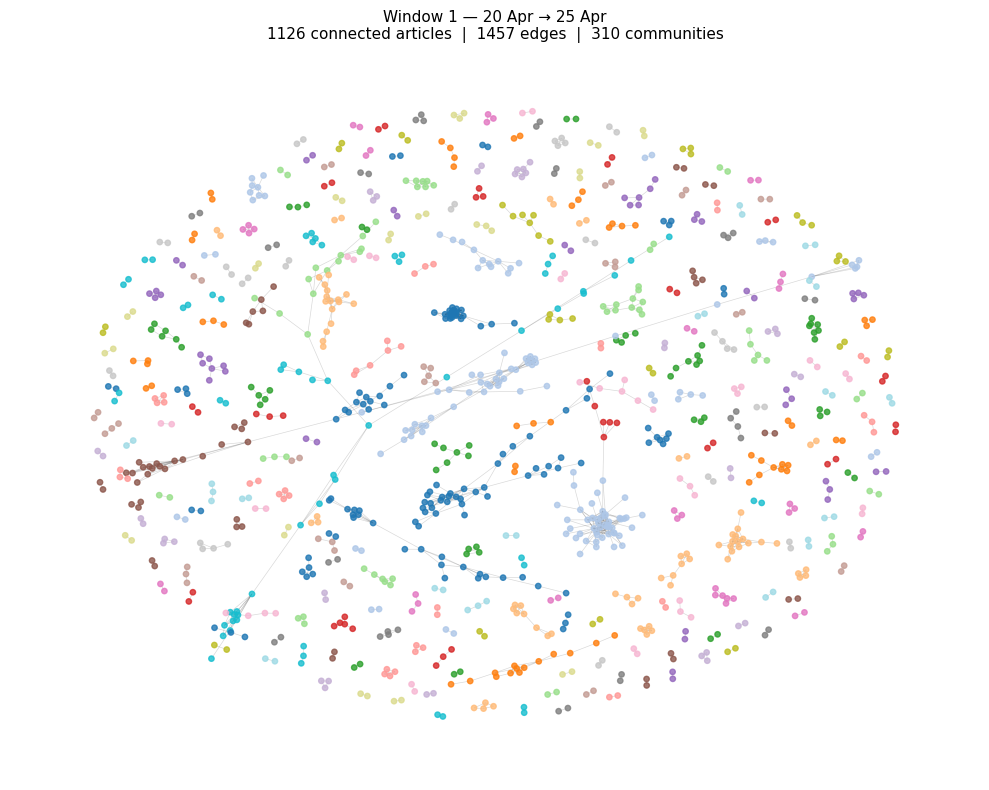

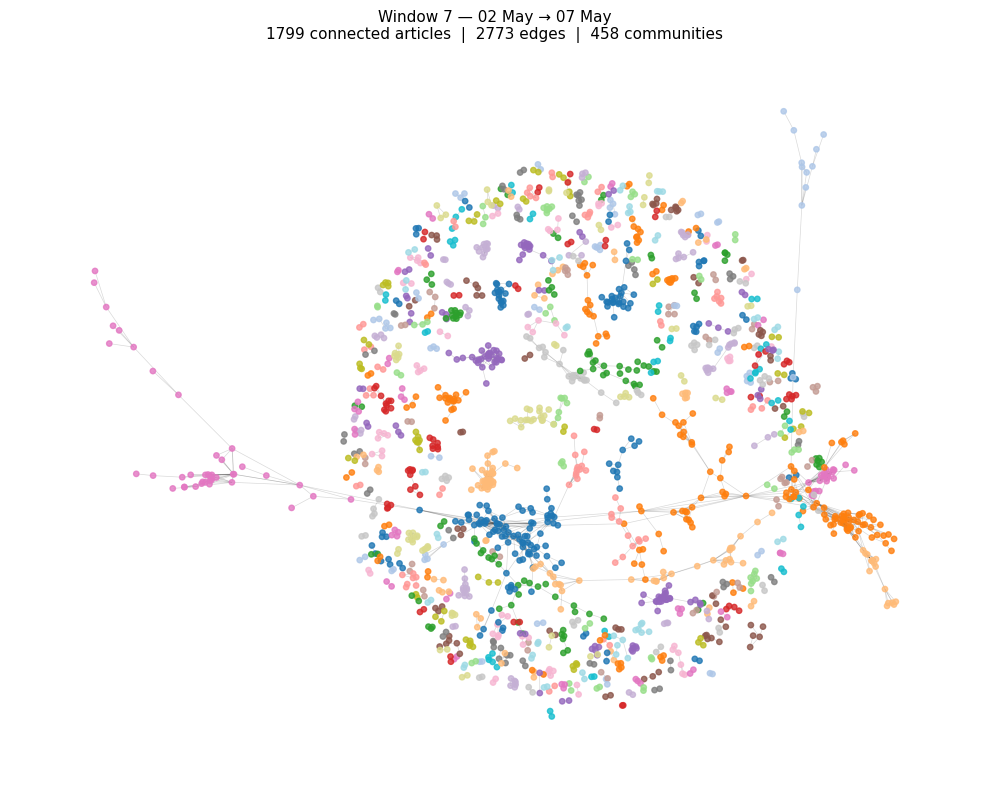

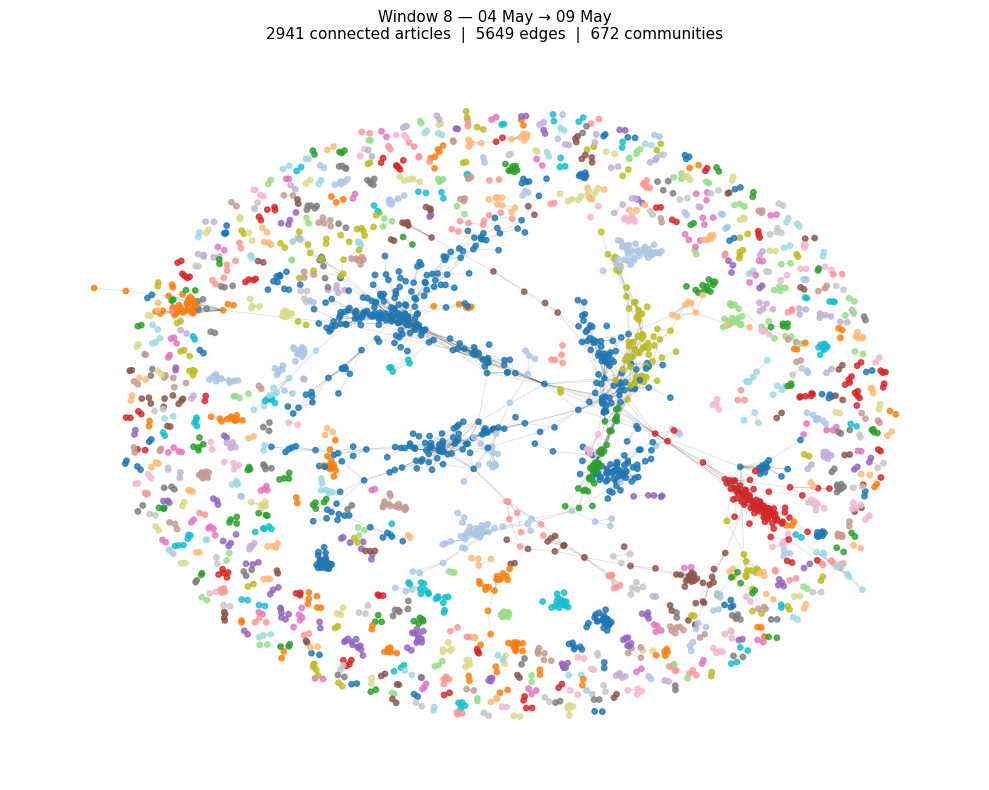

In [16]:
# plot 3 windows
for w in [0, 6, 7]:  # W01, W07, W08
    plot_window_graph(w, topics, windows, dates, df, keywords)

In [17]:
def build_topics(
    df, keywords, dates, windows, T2=5, T_JACCARD=None, random_seed=RANDOM_SEED
):
    """Build keyword graph per sliding window, detect topics via Louvain."""
    window_topics = []
    for ws, we in tqdm(windows, desc="Graph + Louvain"):
        mask = (dates >= ws) & (dates < we)
        win_idx_list = df.index[mask].tolist()
        G = nx.Graph()
        G.add_nodes_from(win_idx_list)
        for i in range(len(win_idx_list)):
            for j in range(i + 1, len(win_idx_list)):
                a, b = win_idx_list[i], win_idx_list[j]
                shared = keywords[a] & keywords[b]
                if len(shared) < T2:
                    continue
                if T_JACCARD is not None:
                    union = keywords[a] | keywords[b]
                    if len(shared) / len(union) < T_JACCARD:
                        continue
                G.add_edge(a, b, weight=len(shared))
        partition = community_louvain.best_partition(G, random_state=random_seed)
        window_topics.append(partition)

    print(f"T2={T2}, T_JACCARD={T_JACCARD} | {len(window_topics)} windows processed")
    for i, p in enumerate(window_topics[:3]):
        print(f"  Window {i+1}: {len(set(p.values()))} topics, {len(p)} articles")
    return window_topics

In [18]:
topics_a = build_topics(df, keywords, dates, windows, T2=3, T_JACCARD=0.15)
topics_b = build_topics(df, keywords, dates, windows, T2=3, T_JACCARD=0.20)
topics_c = build_topics(df, keywords, dates, windows, T2=4, T_JACCARD=0.20)

Graph + Louvain:   0%|          | 0/15 [00:00<?, ?it/s]

T2=3, T_JACCARD=0.15 | 15 windows processed
  Window 1: 1436 topics, 3118 articles
  Window 2: 1497 topics, 3217 articles
  Window 3: 1576 topics, 3244 articles


Graph + Louvain:   0%|          | 0/15 [00:00<?, ?it/s]

T2=3, T_JACCARD=0.2 | 15 windows processed
  Window 1: 1850 topics, 3118 articles
  Window 2: 1899 topics, 3217 articles
  Window 3: 1955 topics, 3244 articles


Graph + Louvain:   0%|          | 0/15 [00:00<?, ?it/s]

T2=4, T_JACCARD=0.2 | 15 windows processed
  Window 1: 1994 topics, 3118 articles
  Window 2: 2027 topics, 3217 articles
  Window 3: 2090 topics, 3244 articles


# Stories building

In [19]:
def build_stories(window_topics, keywords, T3=0.8):
    """Link window topics into stories (majority vote + cross-gap cosine merge)."""
    article_story = {}
    story_kw_vec = {}
    story_alias = {}
    story_last_win = {}
    next_id = [0]

    def resolve(sid):
        while story_alias.get(sid, sid) != sid:
            sid = story_alias[sid]
        return sid

    def create_story(arts, win_idx):
        sid = next_id[0]
        next_id[0] += 1
        story_kw_vec[sid] = Counter()
        for a in arts:
            article_story[a] = sid
            story_kw_vec[sid].update(keywords[a])
        story_last_win[sid] = win_idx

    def assign_to_story(arts, sid, win_idx):
        for a in arts:
            article_story[a] = sid
            story_kw_vec[sid].update(keywords[a])
        story_last_win[sid] = win_idx

    def merge_stories(sid_keep, sid_drop):
        sid_keep = resolve(sid_keep)
        sid_drop = resolve(sid_drop)
        if sid_keep == sid_drop:
            return
        story_alias[sid_drop] = sid_keep
        story_kw_vec[sid_keep].update(story_kw_vec.pop(sid_drop, {}))

    for win_idx, partition in enumerate(tqdm(window_topics, desc="3.2.3 Linking")):
        clusters = defaultdict(list)
        for art_idx, cluster_id in partition.items():
            clusters[cluster_id].append(art_idx)
        for arts in clusters.values():
            prev = [resolve(article_story[a]) for a in arts if a in article_story]
            if not prev:
                create_story(arts, win_idx)
                continue
            vote = Counter(prev)
            top_sid, top_count = vote.most_common(1)[0]
            if top_count > len(arts) / 2:
                for other in list(vote.keys()):
                    if other != top_sid:
                        merge_stories(top_sid, other)
                assign_to_story(arts, top_sid, win_idx)
            else:
                create_story(arts, win_idx)

    canonical_ids = sorted(story_kw_vec.keys())
    dv = DictVectorizer(sparse=True)
    kw_matrix = dv.fit_transform([dict(story_kw_vec[sid]) for sid in canonical_ids])
    kw_norm = normalize(kw_matrix, norm="l2")
    sim_matrix = (kw_norm @ kw_norm.T).tocoo()
    above = (sim_matrix.row < sim_matrix.col) & (sim_matrix.data >= T3)
    pairs = list(zip(sim_matrix.row[above], sim_matrix.col[above]))

    merged_count = 0
    for ri, ci in pairs:
        sid_a = resolve(canonical_ids[ri])
        sid_b = resolve(canonical_ids[ci])
        if sid_a == sid_b:
            continue
        if abs(story_last_win.get(sid_a, -1) - story_last_win.get(sid_b, -1)) > 1:
            merge_stories(sid_a, sid_b)
            merged_count += 1

    story_articles = defaultdict(list)
    for art_idx, sid in article_story.items():
        story_articles[resolve(sid)].append(art_idx)
    story_articles = dict(story_articles)

    sizes = pd.Series({sid: len(arts) for sid, arts in story_articles.items()})
    print(
        f"T3={T3} | Stories: {len(story_articles):,} | Cross-gap merges: {merged_count}"
    )
    print(
        f"Singletons: {(sizes==1).sum()} ({(sizes==1).mean():.1%}) | Largest: {sizes.max()}"
    )
    return story_articles, story_kw_vec, article_story, resolve

In [20]:
stories, kw_vec, article_story, resolve = build_stories(topics, keywords, T3=0.8)

3.2.3 Linking:   0%|          | 0/15 [00:00<?, ?it/s]

T3=0.8 | Stories: 19,009 | Cross-gap merges: 357
Singletons: 15719 (82.7%) | Largest: 497


In [140]:
def print_story(rank, stories, df, keywords):
    story_sizes = sorted(stories.items(), key=lambda x: -len(x[1]))
    sid, arts = story_sizes[rank - 1]

    rows = df.iloc[arts].copy()
    dates_col = (
        rows["published_at_dt"].dt.tz_localize(None)
        if rows["published_at_dt"].dt.tz is not None
        else rows["published_at_dt"]
    )
    rows = rows.assign(date=dates_col.dt.normalize())
    rows = rows.sort_values("date")

    top_kw = Counter()
    for a in arts:
        top_kw.update(keywords[a])

    source_counts = rows["source"].value_counts()

    print(
        f"Story #{rank}  |  sid={sid}  |  {len(arts)} articles  |  {rows['date'].nunique()} days"
    )
    print(f"Date range : {rows['date'].min().date()} → {rows['date'].max().date()}")
    print(f"Keywords   : {', '.join([kw for kw, _ in top_kw.most_common(8)])}")
    print(f"Sources    : {', '.join([f'{s}({n})' for s, n in source_counts.items()])}")
    print("-" * 80)
    for _, row in rows.iterrows():
        print(
            f" {row['published_at_dt']} [{row['source']:<14}]  {row['title']} {row['url']}"
        )
    print()

In [22]:
def plot_story_similarity(rank, stories, df, keywords):
    story_sizes = sorted(stories.items(), key=lambda x: -len(x[1]))
    sid, arts = story_sizes[rank - 1]
    n = len(arts)

    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i][j] = 1.0
                continue
            a, b = arts[i], arts[j]
            u = keywords[a] | keywords[b]
            matrix[i][j] = len(keywords[a] & keywords[b]) / len(u) if u else 0.0

    avg = matrix[np.triu_indices(n, k=1)].mean() if n > 1 else 1.0
    titles = [df.iloc[a]["title"][:40] for a in arts]

    fig, ax = plt.subplots(figsize=(max(6, n * 0.8), max(5, n * 0.7)))
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="YlOrRd")
    plt.colorbar(im, ax=ax, label="Jaccard similarity")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(titles, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(titles, fontsize=7)

    for i in range(n):
        for j in range(n):
            ax.text(
                j,
                i,
                f"{matrix[i][j]:.2f}",
                ha="center",
                va="center",
                fontsize=6,
                color="white" if matrix[i][j] > 0.5 else "black",
            )

    ax.set_title(
        f"Story #{rank}  |  sid={sid}  |  {n} articles  |  avg Jaccard={avg:.3f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

In [23]:
# see how many multi-article stories there are
story_sizes = sorted(stories.items(), key=lambda x: -len(x[1]))
multi = [(sid, arts) for sid, arts in story_sizes if len(arts) > 1]
print(f"Multi-article stories: {len(multi)}")


Multi-article stories: 3290


In [24]:
print_story(len(multi), stories, df, keywords)

Story #3290  |  sid=20017  |  2 articles  |  1 days
Date range : 2026-05-21 → 2026-05-21
Keywords   : куб, хуманитарен, баталя, вашингтон, хаван, сащ
Sources    : vesti(1), fakti(1)
--------------------------------------------------------------------------------
 2026-05-21 03:52:00+00:00 [vesti         ]  "Куба е следваща": Ще има ли война между Вашингтон и Хавана? https://www.vesti.bg/sviat/kuba-e-sledvashta-shte-ima-li-vojna-mezhdu-vashington-i-havana-6260154
 2026-05-21 03:40:01+00:00 [fakti         ]  "Куба е следваща": ще има ли война между Вашингтон и Хавана? https://fakti.bg/mnenia/1055686-kuba-e-sledvashta-shte-ima-li-voina-mejdu-vashington-i-havana



In [25]:
print_story(len(multi) - 2, stories, df, keywords)

Story #3288  |  sid=19944  |  2 articles  |  1 days
Date range : 2026-05-21 → 2026-05-21
Keywords   : авариена, лента, дете, потърпевш, агенция, движа, температура, районен
Sources    : nova(1), 24chasa(1)
--------------------------------------------------------------------------------
 2026-05-21 04:26:54+00:00 [nova          ]  500 евро глоба и отнета книжка за майка, спряла в аварийната лента заради болния си син https://nova.bg/news/view/2026/05/21/537878/500-%D0%B5%D0%B2%D1%80%D0%BE-%D0%B3%D0%BB%D0%BE%D0%B1%D0%B0-%D0%B8-%D0%BE%D1%82%D0%BD%D0%B5%D1%82%D0%B0-%D0%BA%D0%BD%D0%B8%D0%B6%D0%BA%D0%B0-%D0%B7%D0%B0-%D0%BC%D0%B0%D0%B9%D0%BA%D0%B0-%D1%81%D0%BF%D1%80%D1%8F%D0%BB%D0%B0-%D0%B2-%D0%B0%D0%B2%D0%B0%D1%80%D0%B8%D0%B9%D0%BD%D0%B0%D1%82%D0%B0-%D0%BB%D0%B5%D0%BD%D1%82%D0%B0-%D0%B7%D0%B0%D1%80%D0%B0%D0%B4%D0%B8-%D0%B1%D0%BE%D0%BB%D0%BD%D0%B8%D1%8F-%D1%81%D0%B8-%D1%81%D0%B8%D0%BD/
 2026-05-21 04:46:00+00:00 [24chasa       ]  500 евро глоба и отнета книжка за майка, спряла в аварийната ле

In [26]:
print_story(len(multi) - 1, stories, df, keywords)

Story #3289  |  sid=19957  |  2 articles  |  1 days
Date range : 2026-05-21 → 2026-05-21
Keywords   : тръмп, що, аксиос, медия, отнасям, нетанях, премиер, иран
Sources    : 24chasa(1), bta(1)
--------------------------------------------------------------------------------
 2026-05-21 04:23:00+00:00 [24chasa       ]  Тръмп и Нетаняху в спор заради стратегията спрямо Иран https://www.24chasa.bg/mezhdunarodni/article/22889504
 2026-05-21 02:07:00+00:00 [bta           ]  Американски медии пишат, че Тръмп и Нетаняху са влезли в спор заради стратегията спрямо Иран https://www.bta.bg/bg/news/world/1130445-amerikanski-medii-pishat-che-tramp-i-netanyahu-sa-vlezli-v-spor-zaradi-strategi



In [32]:
# stories with 5-15 articles
medium = [
    (i + 1, sid, arts)
    for i, (sid, arts) in enumerate(story_sizes)
    if 5 <= len(arts) <= 15
]
print(f"Medium stories (5-15 articles): {len(medium)}")

for rank, sid, arts in medium[:10]:
    print_story(rank, stories, df, keywords)
    print("=" * 80)

Medium stories (5-15 articles): 421
Story #105  |  sid=171  |  15 articles  |  2 days
Date range : 2026-04-20 → 2026-04-21
Keywords   : катастрофа, движение, апи, километър, лента, трафик, автомобил, съобщя
Sources    : 24chasa(13), actualno(1), fakti(1)
--------------------------------------------------------------------------------
 2026-04-20 16:10:00+00:00 [24chasa       ]  7 българи са ранени при катастрофа с микробус в Малта https://www.24chasa.bg/mezhdunarodni/article/22702794
 2026-04-20 19:21:00+00:00 [24chasa       ]  Турски тир падна в дере край Великотърновско, шофьорът загина (Видео, снимки) https://www.24chasa.bg/bulgaria/article/22703823
 2026-04-20 18:25:00+00:00 [actualno      ]  При тежка катастрофа: Седем българи пострадаха в Малта https://www.actualno.com/crime/pri-tejka-katastrofa-sedem-bylgari-postradaha-v-malta-news_2584088.html
 2026-04-21 12:53:00+00:00 [24chasa       ]  88-годишен катастрофира, дал положителна проба за канабис https://www.24chasa.bg/bulgaria/a

# Evaluate stories

In [141]:
def evaluate_stories(
    stories,
    emb_index_all,
    total_articles,
    n_samples=10000,
    random_seed=42,
    verbose=True,
):
    rng = np.random.default_rng(random_seed)

    cohesions, sizes = [], []
    for sid, arts in stories.items():
        if len(arts) < 3:
            continue
        embs = np.array([emb_index_all[i] for i in arts])
        sim = cos_sim_sk(embs)
        n = len(arts)
        pairs = [sim[i, j] for i in range(n) for j in range(i + 1, n)]
        cohesions.append(np.mean(pairs))
        sizes.append(n)

    story_ids = [sid for sid, arts in stories.items() if len(arts) >= 3]
    inter_scores = []
    while len(inter_scores) < n_samples:
        sid_a, sid_b = rng.choice(story_ids, 2, replace=False)
        a = int(rng.choice(stories[sid_a]))
        b = int(rng.choice(stories[sid_b]))
        inter_scores.append(
            float(cos_sim_sk([emb_index_all[a]], [emb_index_all[b]])[0][0])
        )

    in_stories = sum(len(arts) for arts in stories.values() if len(arts) >= 3)
    coverage = in_stories / total_articles

    mean_coh = np.average(cohesions, weights=sizes)
    mean_sep = np.mean(inter_scores)
    ratio = mean_coh / mean_sep if mean_sep > 0 else float("inf")

    if verbose:
        print(f"Stories evaluated:     {len(cohesions)}")
        print(f"Coverage:              {coverage:.1%} ({in_stories}/{total_articles})")
        print(f"Intra-story coherence: {mean_coh:.4f}")
        print(f"Inter-story similarity:{mean_sep:.4f}")
        print(f"Ratio (coh/sim):       {ratio:.2f}x")

    return {
        "coherence": mean_coh,
        "separation": mean_sep,
        "ratio": ratio,
        "coverage": coverage,
    }

In [127]:
embs_all = np.load("../data/processed/embeddings.npy")
emb_index_all = {i: embs_all[i] for i in range(len(df))}

In [128]:
print(f"Shape: {embs_all.shape}")
print(f"Example embedding (first 10 values): {embs_all[0][:10]}")
print(f"Article: {df.iloc[0]['title']}")

Shape: (30462, 1024)
Example embedding (first 10 values): [ 0.00380297  0.04275529  0.01233156  0.0256576  -0.03185045  0.00624693
  0.03936681  0.00589808  0.01178354  0.03022833]
Article: Радев към DARA: Ти вече си част от европейската политика


In [ ]:
evaluate_stories(stories, emb_index_all)

In [129]:
results_baseline = evaluate_stories(stories, emb_index_all)

Intra-story coherence:   0%|          | 0/19009 [00:00<?, ?it/s]

Stories evaluated:     3290
Intra-story coherence: 0.6935
Inter-story similarity:0.3104
Ratio (coh/sim):       2.23x


In [143]:
T2_values = [5, 6, 7]
T3_values = [0.7, 0.8, 0.9]
total_articles = len(df)

sweep_results = []

for T2 in T2_values:
    print(f"\n{'='*50}")
    print(f"Building topics with T2={T2}...")
    topics_sweep = build_topics(df, keywords, dates, windows, T2=T2)

    for T3 in T3_values:
        print(f"  T3={T3}...")
        stories_sweep, _, _, _ = build_stories(topics_sweep, keywords, T3=T3)
        r = evaluate_stories(
            stories_sweep, emb_index_all, total_articles, verbose=False
        )
        sweep_results.append({"T2": T2, "T3": T3, "n_stories": len(stories_sweep), **r})
        print(
            f"  → {len(stories_sweep)} stories | coverage={r['coverage']:.1%} | coherence={r['coherence']:.4f} | ratio={r['ratio']:.2f}x"
        )

sweep_df = pd.DataFrame(sweep_results)

print("\n=== Coherence ===")
print(sweep_df.pivot(index="T2", columns="T3", values="coherence").round(3))

print("\n=== Inter-story similarity ===")
print(sweep_df.pivot(index="T2", columns="T3", values="separation").round(3))

print("\n=== Ratio ===")
print(sweep_df.pivot(index="T2", columns="T3", values="ratio").round(3))

print("\n=== Coverage ===")
print(sweep_df.pivot(index="T2", columns="T3", values="coverage").round(3))


Building topics with T2=5...


Graph + Louvain:   0%|          | 0/15 [00:00<?, ?it/s]

T2=5, T_JACCARD=None | 15 windows processed
  Window 1: 1924 topics, 3118 articles
  Window 2: 1941 topics, 3217 articles
  Window 3: 2000 topics, 3244 articles
  T3=0.7...


3.2.3 Linking:   0%|          | 0/15 [00:00<?, ?it/s]

T3=0.7 | Stories: 15,241 | Cross-gap merges: 547
Singletons: 12297 (80.7%) | Largest: 2110
  → 15241 stories | coverage=48.9% | coherence=0.5637 | ratio=1.81x
  T3=0.8...


...

T3=0.7 | Stories: 21,544 | Cross-gap merges: 638
Singletons: 18305 (85.0%) | Largest: 357
  → 21544 stories | coverage=27.0% | coherence=0.7015 | ratio=2.24x
  T3=0.8...


3.2.3 Linking:   0%|          | 0/15 [00:00<?, ?it/s]

T3=0.8 | Stories: 21,739 | Cross-gap merges: 355
Singletons: 18489 (85.0%) | Largest: 357
  → 21739 stories | coverage=26.3% | coherence=0.7045 | ratio=2.25x
  T3=0.9...


3.2.3 Linking:   0%|          | 0/15 [00:00<?, ?it/s]

T3=0.9 | Stories: 21,820 | Cross-gap merges: 181
Singletons: 18579 (85.1%) | Largest: 357
  → 21820 stories | coverage=26.0% | coherence=0.7056 | ratio=2.25x

=== Coherence ===
T3    0.7    0.8    0.9
T2                     
5   0.564  0.565  0.565
6   0.647  0.649  0.649
7   0.701  0.705  0.706

=== Inter-story similarity ===
T3    0.7    0.8    0.9
T2                     
5   0.311  0.311  0.310
6   0.312  0.313  0.314
7   0.314  0.313  0.314

=== Ratio ===
T3    0.7    0.8    0.9
T2                     
5   1.812  1.818  1.820
6   2.074  2.072  2.070
7   2.237  2.249  2.249

=== Coverage ===
T3    0.7    0.8    0.9
T2                     
5   0.489  0.484  0.482
6   0.364  0.358  0.356
7   0.270  0.263  0.260


## Parameter Sweep Results — Traditional Story Building

| T2 | T3 | Coherence | Separation | Ratio | Coverage |
|---|---|---|---|---|---|
| 5 | 0.7 | 0.564 | 0.311 | 1.812 | 0.489 |
| 5 | 0.8 | 0.565 | 0.311 | 1.818 | 0.484 |
| 5 | 0.9 | 0.565 | 0.310 | 1.820 | 0.482 |
| 6 | 0.7 | 0.647 | 0.312 | 2.074 | 0.364 |
| **6** | **0.8** ✓ | **0.649** | **0.313** | **2.072** | **0.358** |
| 6 | 0.9 | 0.649 | 0.314 | 2.070 | 0.356 |
| 7 | 0.7 | 0.701 | 0.314 | 2.237 | 0.270 |
| 7 | 0.8 | 0.705 | 0.313 | 2.249 | 0.263 |
| 7 | 0.9 | 0.706 | 0.314 | 2.249 | 0.260 |

**Selected: T2=6, T3=0.8** — best balance between ratio (2.072) and coverage (35.8%).
T2=7 achieves a slightly higher ratio but at the cost of significantly lower coverage (26%).


# Story Quality Evaluation

## Approach

Stories are clusters of articles covering the same real-world news event over time.
Since the pipeline has no ground truth labels, quality is measured using **intrinsic metrics**
based on semantic similarity computed from **BGE-M3 embeddings** (title + first 150 chars of body).

Using embeddings for evaluation is intentionally independent from the keyword-based
pipeline — this avoids circular evaluation and provides a more meaningful semantic
assessment of story quality.

## Metrics

### 1. Intra-story Coherence (Precision proxy)
Mean pairwise BGE-M3 cosine similarity between all articles **within** the same story,
averaged across stories weighted by size. Only stories with ≥ 3 articles are included.

> *Are articles inside the same story semantically similar to each other?*

Higher = better. The primary metric for story quality.

### 2. Inter-story Similarity
Mean cosine similarity between randomly sampled article pairs from **different** stories
(10,000 sampled pairs).

> *How similar are articles from different stories?*

For Bulgarian news this has a **natural floor of ~0.31** regardless of parameters —
all articles share common entities, political figures, and vocabulary. This metric
does not respond meaningfully to parameter changes and is reported for completeness only.

### 3. Coverage (Recall proxy)
Percentage of articles assigned to stories with ≥ 3 articles.

> *How much of the news is captured in meaningful stories?*

Higher = better, but traded off against coherence. Following the paper's reasoning,
**precision (coherence) is prioritised over recall (coverage)** — an ungrouped article
is preferable to a noisy story that mixes unrelated events, especially for timeline
visualisation where incorrect groupings are actively misleading.

### 4. Ratio (Coherence / Inter-story similarity)
Secondary sanity check — how much more similar articles are within stories
compared to across stories.

## Parameter Sweep Results (T2 ∈ {5,6,7}, T3 ∈ {0.7,0.8,0.9})

### Key finding: T3 is irrelevant
Within each T2 value, T3 changes coherence by ≤ 0.002 and coverage by ≤ 0.4%.
T3 = 0.8 (paper default) is kept.

### Precision / Recall trade-off by T2

| T2 | Coherence | Coverage | Ratio |
|---|---|---|---|
| 5 | 0.565 | ~49% | 1.82x |
| **6** | **0.649** | **~36%** | **2.07x** |
| 7 | 0.705 | ~27% | 2.25x |

Inter-story similarity remains flat at ~0.31 across all combinations.

## Selected Parameters: T2=6, T3=0.8

**T2=6** provides the best balance for Bulgarian news:
- Higher coherence than T2=5 (+0.084) with reasonable coverage (36%)
- T2=7 achieves higher coherence but at the cost of leaving 73% of articles ungrouped

**Note on Bulgarian vs English**: The original paper used T2=4 for English.
The higher threshold for Bulgarian reflects the language's morphological richness —
greater vocabulary variation means keyword overlap is naturally lower even for
articles about the same event, requiring a higher baseline threshold to maintain precision.

## Final Baseline Results (T2=6, T3=0.8)

| Metric | Value |
|---|---|
| Stories evaluated (≥3 articles) | 3,290 |
| Intra-story coherence | 0.649 |
| Inter-story similarity | 0.313 |
| Ratio | 2.07x |
| Coverage | 35.8% |


<table style="background-color:#f0f0f0; border-collapse:collapse; width:100%; color:#111">
  <thead>
    <tr style="background-color:#bdbdbd; color:#111">
      <th style="padding:8px; border:1px solid #999">T2</th>
      <th style="padding:8px; border:1px solid #999">T3</th>
      <th style="padding:8px; border:1px solid #999">Coherence</th>
      <th style="padding:8px; border:1px solid #999">Separation</th>
      <th style="padding:8px; border:1px solid #999">Ratio</th>
      <th style="padding:8px; border:1px solid #999">Coverage</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="padding:8px; border:1px solid #999">5</td><td style="padding:8px; border:1px solid #999">0.7</td><td style="padding:8px; border:1px solid #999">0.564</td><td style="padding:8px; border:1px solid #999">0.311</td><td style="padding:8px; border:1px solid #999">1.812</td><td style="padding:8px; border:1px solid #999">0.489</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">5</td><td style="padding:8px; border:1px solid #999">0.8</td><td style="padding:8px; border:1px solid #999">0.565</td><td style="padding:8px; border:1px solid #999">0.311</td><td style="padding:8px; border:1px solid #999">1.818</td><td style="padding:8px; border:1px solid #999">0.484</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">5</td><td style="padding:8px; border:1px solid #999">0.9</td><td style="padding:8px; border:1px solid #999">0.565</td><td style="padding:8px; border:1px solid #999">0.310</td><td style="padding:8px; border:1px solid #999">1.820</td><td style="padding:8px; border:1px solid #999">0.482</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">6</td><td style="padding:8px; border:1px solid #999">0.7</td><td style="padding:8px; border:1px solid #999">0.647</td><td style="padding:8px; border:1px solid #999">0.312</td><td style="padding:8px; border:1px solid #999">2.074</td><td style="padding:8px; border:1px solid #999">0.364</td></tr>
    <tr style="background-color:#a5d6a7; font-weight:bold; color:#111">
      <td style="padding:8px; border:1px solid #999">6 *</td><td style="padding:8px; border:1px solid #999">0.8 *</td><td style="padding:8px; border:1px solid #999">0.649</td><td style="padding:8px; border:1px solid #999">0.313</td><td style="padding:8px; border:1px solid #999">2.072</td><td style="padding:8px; border:1px solid #999">0.358</td>
    </tr>
    <tr><td style="padding:8px; border:1px solid #999">6</td><td style="padding:8px; border:1px solid #999">0.9</td><td style="padding:8px; border:1px solid #999">0.649</td><td style="padding:8px; border:1px solid #999">0.314</td><td style="padding:8px; border:1px solid #999">2.070</td><td style="padding:8px; border:1px solid #999">0.356</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">7</td><td style="padding:8px; border:1px solid #999">0.7</td><td style="padding:8px; border:1px solid #999">0.701</td><td style="padding:8px; border:1px solid #999">0.314</td><td style="padding:8px; border:1px solid #999">2.237</td><td style="padding:8px; border:1px solid #999">0.270</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">7</td><td style="padding:8px; border:1px solid #999">0.8</td><td style="padding:8px; border:1px solid #999">0.705</td><td style="padding:8px; border:1px solid #999">0.313</td><td style="padding:8px; border:1px solid #999">2.249</td><td style="padding:8px; border:1px solid #999">0.263</td></tr>
    <tr><td style="padding:8px; border:1px solid #999">7</td><td style="padding:8px; border:1px solid #999">0.9</td><td style="padding:8px; border:1px solid #999">0.706</td><td style="padding:8px; border:1px solid #999">0.314</td><td style="padding:8px; border:1px solid #999">2.249</td><td style="padding:8px; border:1px solid #999">0.260</td></tr>
  </tbody>
</table>
<p style="color:#111">* Selected configuration</p>